# U.S. crude oil supply, demand, and stocks
## Model review, chronological comparison, and forecast results

**Question:** Which monthly PADD stock model improves on the original constrained regression and on simple baselines—and does that improvement survive a separate evaluation period?

This executed walkthrough reviews the earlier crude implementation and compares **16 approaches**. Five PADD predictions are summed to form the U.S. result. Model selection uses **10 expanding annual test folds**, followed by a separate **24-month evaluation period**. Twelve-month model selection uses **six disjoint development years**, and long-horizon evaluation uses **13 overlapping forecast origins**.

**Target:** Total crude oil stocks **including the Strategic Petroleum Reserve (SPR)**, preserving the earlier model's target. Commercial stocks and the SPR are shown separately. This is an inventory model, not a crude-price model.

Read in order: review findings → data and balance → forecast timing → model candidates → development selection → final evaluation → recursive forecasts → conclusions and reproducibility.

**Everything needed to understand the work is below:** source handling, full feature and model code, a worked validation example, the complete experiment in seven visible stages, diagnostics, conclusions, and checks. No project `.py` imports or external review document are needed. Run All uses the accompanying `data/` snapshots; all result tables and figures are already saved in this notebook.

### Reading guide

1. **Understand the inputs:** Sections 1–3 explain the review, series definitions, missing values, SPR, and balance checks.
2. **Understand the models:** Sections 4–5 show exactly how a forecast row and each candidate are built.
3. **Follow the experiment:** Section 6 runs the full validation and forecast workflow step by step.
4. **Read the evidence:** Sections 7–11 compare results and expose where the models fail.
5. **Reproduce and check:** Section 12 contains the conclusions and integrity checks.

Code cells define the actual functions used below; they are not pseudocode. You can read the prose and saved outputs first, then inspect each implementation in place.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, io, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, duckdb, joblib, sklearn, xgboost
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from IPython.display import display, Markdown

# Only input data are external. No local Python module is imported.
HERE=Path.cwd()
if not (HERE/'data/eia_observations.csv').exists():
    HERE=HERE/'oil'/'us_snd_crude'
assert (HERE/'data/eia_observations.csv').exists(), 'Keep the data folder beside this notebook.'
DATABASE=HERE.parents[1]/'data/commodities.duckdb'  # optional JODI refresh only
OUTPUT=HERE/'model_output'
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')

## 1. What the review changed

| Finding in the original work | Change in this version | Why it matters |
|---|---|---|
| Current-month flows were labeled as next month's stock identity | Reconcile flows in t with the stock change from t−1 to t | Separates correct accounting from lag-based prediction |
| Regional movements, supply adjustments, and transfers were omitted | Download and retain the complete published crude balance | Large apparent regional imbalances are explained |
| The stock target included SPR without emphasizing it | Show total, commercial, and SPR stocks separately | Policy-driven reserve changes can dominate fitted trends |
| All-history CV was the principal assessment | Reserve final 24 months from this experiment's selection | Distinguishes choosing a model from evaluating it |
| One regression was used for the outlook | Compare seasonal baselines, regularization, nonlinear models, recent history, shrinkage, and an ensemble | Improvements must beat simple alternatives |
| Regional selection need not minimize national error | Compare common-family and regional-winner policies on U.S. development MAE | Scores the actual national objective after aggregation |
| One-month validation was used to support 12-month paths | Independently test and select with recursive development forecasts | Evaluates the procedure actually used for the outlook |
| Fitting warnings were suppressed in an earlier notebook | Export all fitting warnings | Makes numerical failures visible |

Original files and results are preserved under `legacy_results_20260905/`. The two older comparison notebooks are marked legacy and import `legacy_crude_model.py`. The original five-feature regression is also **refitted and rescored on exactly the same data and dates** here as `legacy_constrained_level`.

The old regression's lagged-flow inputs were usable predictors; the key timing error was calling its current-flow arithmetic an exact next-month accounting identity. The review does not label all earlier regression results as target leakage.

## 2. Sources, units, and stock scope

The fresh download contains **55 EIA XLS files**, eleven series per PADD. The analysis uses January 2007 onward. Source titles, URLs, timestamps, and SHA-256 hashes are in `data/source_manifest.json`, with original files in `data/raw/`.

Stocks are **thousand barrels at month end**. Flows are **thousand barrels per calendar month**. Divide kb by 1,000 to obtain the million-barrel units shown in charts.

The published crude balance includes net inter-PADD receipts, adjustments, and transfers to crude supply in addition to production, imports, refinery inputs, exports, and direct crude use. See [EIA definitions](https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp) and [the PADD 3 balance](https://www.eia.gov/dnav/pet/pet_sum_snd_d_r30_mbbl_m_cur.htm).

Commercial stock series come from [EIA non-SPR stocks](https://www.eia.gov/dnav/pet/pet_stoc_typ_a_epc0_sax_mbbl_m.htm). SPR stocks are the difference between reported total and commercial stocks, not an estimated allocation. In these data the difference is entirely in PADD 3.

### Series map and input preparation

This is the exact EIA code map and sign convention. `load_panel` reshapes source observations into a complete monthly PADD panel, retains zero assumptions, derives commercial/SPR scope, and calculates historical balance residuals.

In [2]:
PADD_NAMES = {1: 'East Coast', 2: 'Midwest', 3: 'Gulf Coast', 4: 'Rocky Mountain', 5: 'West Coast'}
CODES = {'production_kb': 'MCRFPP{p}1', 'demand_kb': 'MCRRIP{p}1',
         'imports_kb': 'MCRIMP{p}1', 'exports_kb': 'MCREXP{p}1',
         'net_receipts_kb': 'MCRNRP{p}1', 'adjustments_kb': 'MCRUA_R{p}0_1',
         'transfers_kb': 'M_EPC0_TVP_R{p}0_MBBL', 'direct_use_kb': 'MCRUPP{p}1',
         'stock_kb': 'MCRSTP{p}1', 'reported_stock_change_kb': 'MCRSCP{p}1',
         'commercial_stock_kb': 'MCESTP{p}1'}
FLOWS = ['production_kb', 'demand_kb', 'imports_kb', 'exports_kb',
         'net_receipts_kb', 'adjustments_kb', 'transfers_kb', 'direct_use_kb']
SIGNS = [1, -1, 1, -1, 1, 1, 1, -1]
# The downloaded transfer series start in January 2022; earlier rows are structural zeros.
SPARSE = {'exports_kb', 'transfers_kb', 'net_receipts_kb'}

In [3]:
def load_panel(data_dir=HERE / 'data', start='2007-01-01'):
    raw = pd.read_csv(Path(data_dir) / 'eia_observations.csv', parse_dates=['month'])
    if raw.duplicated(['month', 'padd', 'component']).any():
        raise ValueError('Duplicate EIA observations')
    panels = []
    for p in PADD_NAMES:
        r = raw[raw.padd.eq(p)]
        end = r[r.component.eq('stock_kb') & r.value.notna()].month.max()
        index = pd.date_range(start, end, freq='MS')
        wide = r.pivot(index='month', columns='component', values='value').reindex(index)
        for c in SPARSE:
            rows = r[r.component.eq(c)].set_index('month')
            # Missing calendar rows in sparse export/transfer sheets are an explicit
            # no-reported-flow assumption, not interpolation from future values.
            absent = ~wide.index.isin(rows.index)
            wide[c + '_assumed_zero'] = rows.assumed_zero.reindex(index).astype("boolean").fillna(False).astype(bool) | absent
            wide.loc[absent, c] = 0.0
        wide['padd'] = p
        wide['padd_name'] = PADD_NAMES[p]
        wide.index.name = 'month'
        panels.append(wide.reset_index())
    panel = pd.concat(panels, ignore_index=True)
    core = FLOWS + ['stock_kb', 'reported_stock_change_kb', 'commercial_stock_kb']
    valid = panel[core].notna().all(axis=1)
    common = panel[valid].groupby('month').padd.nunique()
    end = common[common.eq(5)].index.max()
    panel = panel[panel.month.le(end)].copy()
    if panel[core].isna().any().any():
        raise ValueError('Unresolved missing core data; inspect the source snapshots')
    if not panel.groupby('padd').size().eq(len(pd.date_range(start, end, freq='MS'))).all():
        raise ValueError('Incomplete PADD calendar')
    panel['spr_stock_kb'] = panel.stock_kb - panel.commercial_stock_kb
    panel['previous_stock_kb'] = panel.groupby('padd').stock_kb.shift(1)
    panel['balance_kb'] = panel[FLOWS].to_numpy() @ SIGNS
    panel['stock_change_kb'] = panel.stock_kb - panel.previous_stock_kb
    panel['five_term_balance_kb'] = panel.production_kb + panel.imports_kb - panel.demand_kb - panel.exports_kb
    panel['five_term_residual_kb'] = panel.stock_change_kb - panel.five_term_balance_kb
    panel['accounting_residual_kb'] = panel.stock_change_kb - panel.balance_kb
    panel['reported_change_residual_kb'] = panel.stock_change_kb - panel.reported_stock_change_kb
    return panel

### Optional data collection, included for completeness

The downloader below preserves the XLS source bytes and their hashes, normalizes EIA observations, and snapshots JODI from DuckDB. It is defined here but **not called** during the normal offline run. Set `REFRESH_SOURCES=True` only when you want fresh EIA data and have the local JODI database available. Changing the snapshot may change dates and results.

In [4]:
def refresh_data(data_dir=HERE / 'data', database=DATABASE):
    data_dir = Path(data_dir)
    raw_dir = data_dir / 'raw'
    raw_dir.mkdir(parents=True, exist_ok=True)
    def download(task):
        p, component, code = task
        url = f'https://www.eia.gov/dnav/pet/hist_xls/{code}m.xls'
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        content = response.content
        table = pd.read_excel(io.BytesIO(content), sheet_name='Data 1', header=2, keep_default_na=False)
        if table.shape[1] != 2 or 'Thousand Barrels' not in str(table.columns[1]):
            raise ValueError(f'Unexpected units/schema: {code}')
        (raw_dir / f'{code}m.xls').write_bytes(content)
        original = table.iloc[:, 1]
        values = pd.to_numeric(original, errors='coerce')
        # Excel empty cells correspond to no-data-reported on these sparse series.
        # Preserve text markers so W/NA cannot silently turn into zero.
        empty = original.isna() | original.astype(str).str.strip().isin(['', '-'])
        zero = values.isna() & empty & (component in SPARSE)
        values = values.mask(zero, 0.0)
        frame = pd.DataFrame({'month': pd.to_datetime(table.iloc[:, 0]).dt.to_period('M').dt.to_timestamp(),
            'padd': p, 'component': component, 'value': values, 'assumed_zero': zero, 'series_id': code})
        # Sparse worksheets sometimes stop before the common archive endpoint;
        # calendar extension is handled explicitly by load_panel, with flags.
        meta = {'padd': p, 'component': component, 'series_id': code, 'url': url,
                'title': str(table.columns[1]), 'sha256': hashlib.sha256(content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        return frame, meta
    tasks = [(p, c, template.format(p=p)) for p in PADD_NAMES for c, template in CODES.items()]
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = list(pool.map(download, tasks))
    raw = pd.concat([r[0] for r in results], ignore_index=True)
    raw.to_csv(data_dir / 'eia_observations.csv', index=False)
    (data_dir / 'source_manifest.json').write_text(json.dumps([r[1] for r in results], indent=2))
    with duckdb.connect(str(database), read_only=True) as con:
        jodi = con.execute("""SELECT time_period, flow_breakdown, obs_value, assessment_code
            FROM fundamental.jodi_observation WHERE ref_area='US'
            AND energy_product='CRUDEOIL' AND unit_measure='KBBL'""").fetchdf()
    jodi.to_csv(data_dir / 'jodi_us_raw.csv', index=False)
    (data_dir / 'jodi_source.json').write_text(json.dumps({'database': str(database),
        'table': 'fundamental.jodi_observation', 'product': 'CRUDEOIL', 'unit': 'KBBL',
        'snapshot_utc': datetime.now(timezone.utc).isoformat()}, indent=2))
    return load_panel(data_dir)

In [5]:
REFRESH_SOURCES = False
if REFRESH_SOURCES:
    refresh_data(HERE/'data', database=DATABASE)

In [6]:
panel=load_panel(HERE/'data')
manifest=pd.read_json(HERE/'data/source_manifest.json')
display(manifest[manifest.padd.eq(3)][['component','series_id','title']])
display(panel.groupby('padd').agg(start=('month','min'),end=('month','max'),months=('month','size')))
flags=[c for c in panel if c.endswith('_assumed_zero')]
display(panel.groupby('padd')[flags].sum())

,component,series_id,title
22,production_kb,MCRFPP31,Gulf Coast (PADD 3) Field Production of Crude ...
23,demand_kb,MCRRIP31,Gulf Coast (PADD 3) Refinery and Blender Net I...
24,imports_kb,MCRIMP31,Gulf Coast (PADD 3) Imports of Crude Oil (Thou...
25,exports_kb,MCREXP31,Gulf Coast (PADD 3) Exports of Crude Oil (Thou...
26,net_receipts_kb,MCRNRP31,"Gulf Coast (PADD 3) Net Receipts by Pipeline, ..."
27,adjustments_kb,MCRUA_R30_1,Gulf Coast (PADD 3) Supply Adjustment of Crude...
28,transfers_kb,M_EPC0_TVP_R30_MBBL,Gulf Coast (PADD 3) Transfers to Crude Oil Sup...
29,direct_use_kb,MCRUPP31,Gulf Coast (PADD 3) Product Supplied of Crude ...
30,stock_kb,MCRSTP31,Gulf Coast (PADD 3) Ending Stocks of Crude Oil...
31,reported_stock_change_kb,MCRSCP31,Gulf Coast (PADD 3) Crude Oil Stock Change (Th...


,start,end,months
padd,,,
1,2007-01-01,2026-06-01,234
2,2007-01-01,2026-06-01,234
3,2007-01-01,2026-06-01,234
4,2007-01-01,2026-06-01,234
5,2007-01-01,2026-06-01,234


component,net_receipts_kb_assumed_zero,transfers_kb_assumed_zero,exports_kb_assumed_zero
padd,,,
1,0,180,21
2,0,180,0
3,0,180,63
4,0,180,98
5,43,180,103


No-data-reported/absent cells in exports and net receipts are explicitly assumed zero and flagged. The transfer series begin in January 2022; earlier transfer rows are structural zeros in the published-category reconstruction. These are reporting conventions, not claims that the underlying physical processes were absent. Unavailable/withheld text markers remain missing; unresolved core data fail validation. The loader requires a common complete endpoint and monthly calendar for all five PADDs.

The review also corrected the shared downloader's Excel parsing: literal `NA` markers must remain distinct from blank cells. No explicit unavailable markers occur in the current analysis history, so this parser correction does not alter the saved gasoline results.

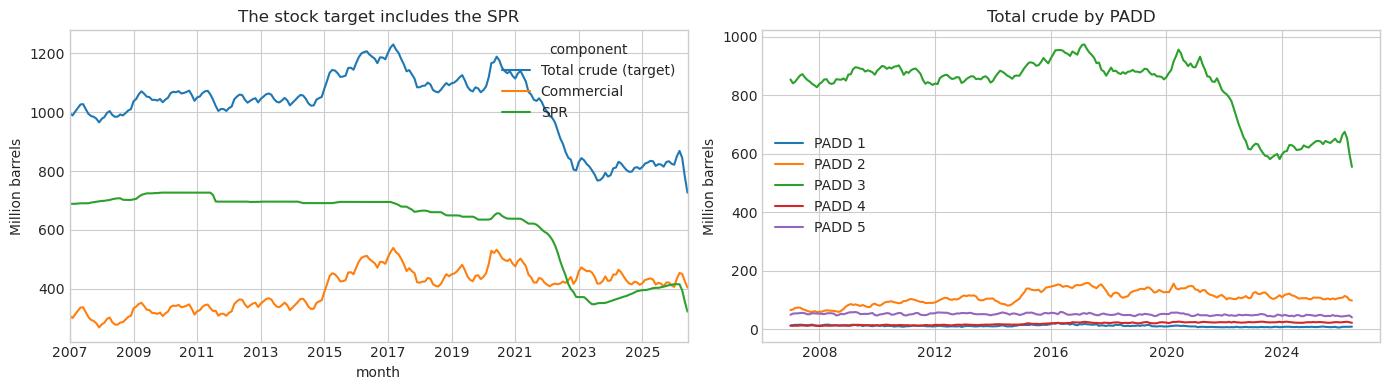

In [7]:
national_history=panel.groupby('month')[['stock_kb','commercial_stock_kb','spr_stock_kb']].sum()
fig,axes=plt.subplots(1,2,figsize=(14,4))
(national_history/1000).rename(columns={'stock_kb':'Total crude (target)','commercial_stock_kb':'Commercial','spr_stock_kb':'SPR'}).plot(ax=axes[0])
for p,g in panel.groupby('padd'):
    axes[1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[0].set_title('The stock target includes the SPR');axes[1].set_title('Total crude by PADD');axes[1].legend()
for ax in axes:ax.set_ylabel('Million barrels')
plt.tight_layout();plt.show()

## 3. Reconstruct the balance before forecasting

\[
S_t-S_{t-1}=P_t+I_t+N_t+A_t+T_t-R_t-X_t-U_t+\epsilon_t
\]

| Symbol | Meaning |
|---|---|
| S | Total crude stocks including SPR |
| P / I | Field production / imports |
| N / A / T | Net receipts / supply adjustments / transfers to crude supply |
| R / X / U | Refinery input / exports / direct crude use |
| ε | Remaining accounting/reporting difference |

The original five-term balance omitted N, A, T, and U. The revised residual is much smaller. A small historical residual validates alignment and coverage, **not forecast skill**: published balancing terms are not all independently measured information.

,old_balance_mae_kb,complete_balance_mae_kb,max_complete_residual_kb
padd,,,
1,"4,925.73",0.29,1.00
2,"25,107.82",0.56,60.00
3,"34,814.03",0.31,1.00
4,"14,072.37",0.31,6.00
5,"4,475.74",0.27,1.00


component,month,padd,accounting_residual_kb,reported_change_residual_kb
462,2026-01-01,2,60.00,60.00
930,2026-01-01,4,6.00,6.00


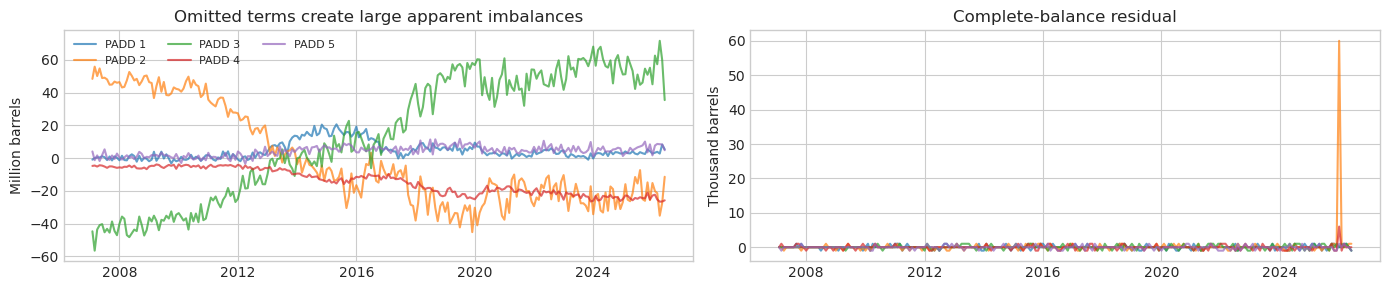

In [8]:
audit=panel.groupby('padd').agg(
    old_balance_mae_kb=('five_term_residual_kb',lambda s:s.abs().mean()),
    complete_balance_mae_kb=('accounting_residual_kb',lambda s:s.abs().mean()),
    max_complete_residual_kb=('accounting_residual_kb',lambda s:s.abs().max()))
display(audit)
exceptions=panel[panel.accounting_residual_kb.abs()>2]
display(exceptions[['month','padd','accounting_residual_kb','reported_change_residual_kb']])
fig,axes=plt.subplots(1,2,figsize=(14,3))
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month,g.five_term_residual_kb/1000,label=f'PADD {p}',alpha=.7)
    axes[1].plot(g.month,g.accounting_residual_kb,label=f'PADD {p}',alpha=.7)
axes[0].set(title='Omitted terms create large apparent imbalances',ylabel='Million barrels')
axes[1].set(title='Complete-balance residual',ylabel='Thousand barrels')
axes[0].legend(ncol=3,fontsize=8);plt.tight_layout();plt.show()

Two exceptions remain in January 2026: 60 kb in PADD 2 and 6 kb in PADD 4. They also appear when comparing month-end stock differences with EIA's separately reported stock-change series. We retain them as source/reporting discrepancies rather than forcing the balance to close. Other residuals are at rounding scale.

## 4. Forecast timing and what the evaluation can establish

Each row predicts ending stock in month **t**, using stock and flow observations only through **t−1**, plus the known calendar month. Features contain lagged stock levels, the latest stock change, signed lagged flows, and optional seasonality. Actual target-month flows are never predictive inputs.

The flow-identity baseline forecasts target-month flows from the previous 60 months of daily rates, using a linear trend and month fixed effects. Multiplication by the target month's day count handles February and 30/31-day months. Main production, refinery demand, imports, and exports receive a zero floor; net receipts, adjustments, and transfers retain their signs.

This is a **conditional latest-vintage historical evaluation**. EIA releases monthly data with a delay and revises it. We have not reconstructed exactly what was available on each historical release date. Earlier crude notebooks also examined some of these dates, so the final 24 months are held out of **this experiment's selection**, not a never-before-seen prospective dataset. The long-horizon protocol was added during this review after observing that one-step selection was inadequate; its selection uses development data only, but the review as a whole is retrospective.

### Build a forecast row from past observations

`forecast_flows` converts monthly volumes to daily rates, fits trend and calendar effects on earlier observations, then converts forecasts back to monthly volumes. `feature_row` reads only the supplied history. `supervised` stops that history immediately before each target month and attaches the target separately.

In [9]:
def seasonal_design(months, origin):
    dates = pd.DatetimeIndex(months)
    trend = ((dates.year - origin.year) * 12 + dates.month - origin.month).to_numpy() / 12
    return np.column_stack([trend] + [(dates.month == m).astype(float) for m in range(2, 13)])


def forecast_flows(history, months):
    """Fit monthly daily-rate seasonality + trend on the last 60 observed months."""
    train = history.tail(60)
    model = LinearRegression()
    model.fit(seasonal_design(train.month, train.month.iloc[0]),
              train[FLOWS].to_numpy() / train.month.dt.days_in_month.to_numpy()[:, None])
    rates = model.predict(seasonal_design(months, train.month.iloc[0]))
    flows = rates * pd.DatetimeIndex(months).days_in_month.to_numpy()[:, None]
    for c in ['production_kb', 'demand_kb', 'imports_kb', 'exports_kb']:
        flows[:, FLOWS.index(c)] = np.maximum(flows[:, FLOWS.index(c)], 0)
    # Net receipts, adjustments and transfers can be negative.
    return pd.DataFrame(flows, columns=FLOWS, index=pd.DatetimeIndex(months))

In [10]:
def feature_row(history, month):
    last = history.iloc[-1]
    row = {'stock_lag1': last.stock_kb, 'stock_lag12': history.iloc[-12].stock_kb,
           'change_lag1': last.stock_kb - history.iloc[-2].stock_kb,
           'sin_month': np.sin(2*np.pi*month.month/12), 'cos_month': np.cos(2*np.pi*month.month/12)}
    changes = history.set_index('month').stock_kb.diff().tail(60)
    seasonal = changes[changes.index.month == month.month].dropna()
    row['seasonal_change'] = float(seasonal.mean()) if len(seasonal) else 0.0
    row.update({'lag_' + c: last[c] * sign for c, sign in zip(FLOWS, SIGNS)})
    return row


def supervised(history):
    rows = []
    for i in range(12, len(history)):
        past, current = history.iloc[:i], history.iloc[i]
        row = feature_row(past, current.month)
        flow = forecast_flows(past, [current.month]).iloc[0]
        row.update(month=current.month, origin_month=past.month.iloc[-1],
                   actual_kb=current.stock_kb, delta_kb=current.stock_kb-past.stock_kb.iloc[-1],
                   forecast_flow_identity=max(0.0, past.stock_kb.iloc[-1] + flow.to_numpy() @ SIGNS))
        rows.append(row)
    return pd.DataFrame(rows)

In [11]:
example=supervised(panel[panel.padd.eq(3)].reset_index(drop=True))
display(example[['origin_month','month','stock_lag1','lag_production_kb','lag_demand_kb',
                 'forecast_flow_identity','actual_kb']].tail())
assert (example.origin_month<example.month).all()

,origin_month,month,stock_lag1,lag_production_kb,lag_demand_kb,forecast_flow_identity,actual_kb
217,2026-01-01,2026-02-01,"639,513.00","305,326.00","-276,138.00","656,072.83","665,153.00"
218,2026-02-01,2026-03-01,"665,153.00","285,912.00","-244,527.00","680,134.49","675,361.00"
219,2026-03-01,2026-04-01,"675,361.00","315,913.00","-287,565.00","681,955.32","653,282.00"
220,2026-04-01,2026-05-01,"653,282.00","313,194.00","-280,808.00","653,237.99","599,784.00"
221,2026-05-01,2026-06-01,"599,784.00","316,855.00","-296,239.00","593,257.42","555,461.00"


## 5. Sixteen candidates, with fixed settings

| Model | Specification | Main control |
|---|---|---|
| Persistence | Carry the latest stock forward | No fitting |
| Seasonal naive | Same month's stock last year | No fitting |
| Seasonal change | Latest stock + mean same-month change in trailing 60 months | Five-year history; zero change if no seasonal observation |
| Forecast-flow identity | Latest stock + forecast complete flow balance | 60-month daily-rate trend/seasonality |
| Legacy constrained level | Original stock + four signed lagged flows | Nonnegative coefficients |
| Complete constrained level | Stock + all eight signed lagged flows | Nonnegative coefficients |
| Ridge change | Monthly stock change on lagged stocks/flows | Standardization; α=100 |
| Seasonal ridge change | Ridge change plus calendar sine/cosine | α=100 |
| Polynomial ridge change | Quadratic seasonal-feature interactions | Standardization; α=1,000 |
| Spline ridge change | Smooth feature effects | Four knots, degree 2; α=100 |
| Random forest change | Stock-change forest | 150 trees, depth 4, minimum leaf 12 |
| XGBoost change | Boosted stock-change trees | 120 trees, depth 2, learning rate .03, L2=30 |
| Neural network change | Stock-change network | 16 hidden units, α=10; feature/target scaling |
| Rolling ridge change | Seasonal ridge using only last 60 training rows | Tests adaptation to recent regimes |
| Damped ridge change | Half of seasonal ridge's predicted change | Shrinks toward persistence |
| Ensemble change | Equal mean of seasonal ridge, forest, and XGBoost changes | Tests model averaging |

All transformations fit on training data only, all models are deterministic, and stock predictions have a zero floor. The neural network uses L-BFGS without random early-stopping splits. Nonlinear models predict stock **changes** and add them to the latest stock, which avoids requiring trees to extrapolate the absolute stock level. Regression coefficients are predictive associations, not causal physical elasticities.

### Exact model definitions

These constants specify the feature sets. `estimator` declares every learned model and its settings. `fit` chooses stock level or stock change as the target; `predict` converts changes back into levels and implements the simple baselines.

In [12]:
BASELINES = ['persistence', 'seasonal_naive', 'seasonal_change', 'forecast_flow_identity']
LEARNED = ['legacy_constrained_level', 'constrained_level', 'ridge_change', 'seasonal_ridge_change',
           'polynomial_ridge_change', 'spline_ridge_change', 'random_forest_change',
           'xgboost_change', 'neural_network_change', 'rolling_ridge_change',
           'damped_ridge_change', 'ensemble_change']
MODELS = BASELINES + LEARNED
BASE_FEATURES = ['stock_lag1', 'stock_lag12', 'change_lag1'] + ['lag_' + c for c in FLOWS]
FEATURES = BASE_FEATURES + ['sin_month', 'cos_month']

In [13]:
def columns(name):
    if name == 'legacy_constrained_level':
        return ['stock_lag1'] + ['lag_' + c for c in FLOWS[:4]]
    if name == 'constrained_level':
        return ['stock_lag1'] + ['lag_' + c for c in FLOWS]
    if name == 'ridge_change':
        return BASE_FEATURES
    return FEATURES


def estimator(name):
    if name in ['constrained_level', 'legacy_constrained_level']:
        return LinearRegression(positive=True)
    if name in ['ridge_change', 'seasonal_ridge_change', 'rolling_ridge_change', 'damped_ridge_change']:
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'polynomial_ridge_change':
        return make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                             StandardScaler(), Ridge(alpha=1000))
    if name == 'spline_ridge_change':
        return make_pipeline(SplineTransformer(n_knots=4, degree=2, extrapolation='linear'),
                             StandardScaler(), Ridge(alpha=100))
    if name == 'random_forest_change':
        return RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12,
                                     max_features=0.8, n_jobs=1, random_state=42)
    if name == 'xgboost_change':
        return XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03,
            min_child_weight=12, reg_lambda=30, subsample=0.8, colsample_bytree=0.8,
            n_jobs=1, random_state=42, objective='reg:squarederror')
    if name == 'neural_network_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            MLPRegressor(hidden_layer_sizes=(16,), alpha=10, solver='lbfgs',
                         max_iter=3000, random_state=42)), transformer=StandardScaler())
    if name == 'ensemble_change':
        return VotingRegressor([(n, estimator(n)) for n in
            ['seasonal_ridge_change', 'random_forest_change', 'xgboost_change']])
    raise ValueError(name)

In [14]:
def fit(name, train):
    if name in BASELINES:
        return None, ''
    model = estimator(name)
    if name == 'rolling_ridge_change':
        train = train.tail(60)
    target = 'actual_kb' if name in ['constrained_level', 'legacy_constrained_level'] else 'delta_kb'
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        model.fit(train[columns(name)], train[target])
    return model, '; '.join(str(w.message) for w in caught)


def predict(name, model, frame):
    if name == 'persistence':
        return frame.stock_lag1.to_numpy()
    if name == 'seasonal_naive':
        return frame.stock_lag12.to_numpy()
    if name == 'seasonal_change':
        return np.maximum(0, frame.stock_lag1.to_numpy() + frame.seasonal_change.to_numpy())
    if name == 'forecast_flow_identity':
        return frame.forecast_flow_identity.to_numpy()
    prediction = model.predict(frame[columns(name)])
    if name == 'damped_ridge_change':
        prediction *= 0.5
    if name not in ['constrained_level', 'legacy_constrained_level']:
        prediction += frame.stock_lag1.to_numpy()
    return np.maximum(prediction, 0)

### How errors and national totals are calculated

MAE averages absolute errors; RMSE squares errors before averaging and taking a square root; R² compares squared errors with variation around the evaluation sample mean. `aggregate` checks five distinct PADDs for every key before summing—regional MAEs are never added to obtain national MAE.

In [15]:
def score(actual, predicted):
    return {'mae_kb': mean_absolute_error(actual, predicted),
            'rmse_kb': mean_squared_error(actual, predicted)**0.5,
            'r2': r2_score(actual, predicted), 'n': len(actual)}


def aggregate(frame, keys, additive):
    """Reject partial U.S. totals instead of silently summing fewer than five PADDs."""
    if frame.duplicated(keys + ['padd']).any():
        raise ValueError('Duplicate PADD rows in aggregation')
    if not frame.groupby(keys).padd.nunique().eq(5).all():
        raise ValueError('U.S. aggregation requires all five PADDs')
    return frame.groupby(keys, as_index=False)[additive].sum(min_count=5)


def metric_table(predictions, keys):
    return pd.DataFrame([{**dict(zip(keys, k if isinstance(k, tuple) else (k,))),
        **score(g.actual_kb, g.predicted_kb)} for k,g in predictions.groupby(keys)])

### One worked fold, before the full comparison

This small example trains the original constrained model for PADD 3 on the first development training window, predicts the following year, and shows each error. It uses the same `fit`, `predict`, and `score` functions as the full experiment.

In [16]:
worked = supervised(panel[panel.padd.eq(3)].reset_index(drop=True))
development_example = worked.iloc[:-24]
train_idx, test_idx = next(TimeSeriesSplit(n_splits=10, test_size=12).split(development_example))
train_example, test_example = development_example.iloc[train_idx], development_example.iloc[test_idx]
example_model, example_warning = fit('legacy_constrained_level', train_example)
example_predictions = predict('legacy_constrained_level', example_model, test_example)
worked_results = test_example[['origin_month','month','actual_kb']].copy()
worked_results['predicted_kb'] = example_predictions
worked_results['absolute_error_kb'] = abs(worked_results.actual_kb-worked_results.predicted_kb)
print('Training targets:',train_example.month.min().date(),'to',train_example.month.max().date())
display(worked_results)
display(pd.Series(score(test_example.actual_kb,example_predictions),name='Worked-fold scores'))
assert train_example.month.max() < test_example.month.min()

Training targets: 2008-01-01 to 2014-06-01


,origin_month,month,actual_kb,predicted_kb,absolute_error_kb
78,2014-06-01,2014-07-01,"867,623.00","875,227.12","7,604.12"
79,2014-07-01,2014-08-01,"863,183.00","866,549.69","3,366.69"
80,2014-08-01,2014-09-01,"856,901.00","863,327.15","6,426.15"
81,2014-09-01,2014-10-01,"866,769.00","860,841.89","5,927.11"
82,2014-10-01,2014-11-01,"868,014.00","872,016.16","4,002.16"
83,2014-11-01,2014-12-01,"867,012.00","871,747.73","4,735.73"
84,2014-12-01,2015-01-01,"880,450.00","867,653.07","12,796.93"
85,2015-01-01,2015-02-01,"893,237.00","884,074.23","9,162.77"
86,2015-02-01,2015-03-01,"902,630.00","897,581.94","5,048.06"
87,2015-03-01,2015-04-01,"912,245.00","903,859.55","8,385.45"


mae_kb    6,375.79
rmse_kb   6,889.09
r2            0.89
n            12.00
Name: Worked-fold scores, dtype: float64

In [17]:
assert len(MODELS)==16
print('Complete constrained features:',columns('constrained_level'))
print('Legacy features:',columns('legacy_constrained_level'))
print(estimator('neural_network_change'))
print(estimator('ensemble_change'))

Complete constrained features: ['stock_lag1', 'lag_production_kb', 'lag_demand_kb', 'lag_imports_kb', 'lag_exports_kb', 'lag_net_receipts_kb', 'lag_adjustments_kb', 'lag_transfers_kb', 'lag_direct_use_kb']
Legacy features: ['stock_lag1', 'lag_production_kb', 'lag_demand_kb', 'lag_imports_kb', 'lag_exports_kb']
TransformedTargetRegressor(regressor=Pipeline(steps=[('standardscaler',
                                                      StandardScaler()),
                                                     ('mlpregressor',
                                                      MLPRegressor(alpha=10,
                                                                   hidden_layer_sizes=(16,),
                                                                   max_iter=3000,
                                                                   random_state=42,
                                                                   solver='lbfgs'))]),
                           transformer=StandardSca

## 6. Rebuild the experiment

The following cells fit and evaluate all candidates from the saved inputs. It does not download data or write to the shared database; allow a few minutes.

**One-month selection:** Ten expanding folds each test 12 months. Learned parameters remain fixed within a fold while prior-month observations update. Baseline seasonal rules update using only available past data. We compare the mix of regional CV winners with every common model-family policy after summing five PADDs. Lowest national development MAE selects deployment.

**Twelve-month selection:** Six disjoint development years compare complete recursive paths for all 16 candidates. Lowest national MAE across their 72 forecast months selects the long-horizon policy separately. All six years end before the final evaluation period.

CV scores used for selection are optimistic. The final 24-month results measure subsequent performance; their best-in-hindsight model does not replace the selected policy.

### The chronological evaluation loop

The implementation below fits transformations and models separately in each training fold, collects every out-of-fold prediction, chooses regional winners from development errors, and scores the final period without using it to choose a winner. Warning messages are retained.

In [18]:
def evaluate(samples, folds=10, holdout=24):
    """Choose models only on development CV; score untouched final 24 months."""
    predictions, fold_metrics, selections, fitted, warning_rows = [], [], [], {}, []
    for padd, frame in samples.items():
        development = frame.iloc[:-holdout]
        if len(development) - folds*12 < 36:
            raise ValueError('Need >=36 initial training months plus 10 annual folds and holdout')
        splits = list(TimeSeriesSplit(n_splits=folds, test_size=12).split(development))
        for name in MODELS:
            for fold, (tr, te) in enumerate(splits, 1):
                train, test = development.iloc[tr], development.iloc[te]
                model, warning = fit(name, train)
                pred = predict(name, model, test)
                fold_metrics.append(dict(padd=padd, model=name, fold=fold,
                    train_end=train.month.max(), test_start=test.month.min(), test_end=test.month.max(),
                    train_mae_kb=mean_absolute_error(train.actual_kb, predict(name, model, train)),
                    **score(test.actual_kb, pred)))
                output = test[['month', 'origin_month', 'actual_kb']].copy()
                output['predicted_kb'], output['padd'], output['model'] = pred, padd, name
                output['split'], output['fold'] = 'cv', fold
                predictions.append(output)
                if warning:
                    warning_rows.append(dict(padd=padd, model=name, stage=f'cv_{fold}', warning=warning))
        current = pd.concat(predictions, ignore_index=True)
        current = current[current.padd.eq(padd)]
        losses = current.assign(error=lambda x: abs(x.actual_kb-x.predicted_kb)).groupby('model').error.mean()
        winner = losses.idxmin()
        selections.append(dict(padd=padd, selected_model=winner, cv_mae_kb=losses[winner]))
        for name in MODELS:
            model, warning = fit(name, development)
            test = frame.iloc[-holdout:]
            output = test[['month', 'origin_month', 'actual_kb']].copy()
            output['predicted_kb'] = predict(name, model, test)
            output['padd'], output['model'], output['split'], output['fold'] = padd, name, 'holdout', 0
            predictions.append(output)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='holdout', warning=warning))
        final, warning = fit(winner, frame)
        fitted[padd] = {'name': winner, 'estimator': final}
        if warning:
            warning_rows.append(dict(padd=padd, model=winner, stage='final', warning=warning))
        print(f'PADD {padd}: selected {winner}; CV MAE {losses[winner]:,.1f} kb', flush=True)
    return (pd.concat(predictions, ignore_index=True), pd.DataFrame(fold_metrics),
            pd.DataFrame(selections), fitted,
            pd.DataFrame(warning_rows, columns=['padd','model','stage','warning']))

### The recursive forecast implementation

For a year-long path, forecast all flows using history at the origin. Then predict one stock at a time and append that predicted month to the history used for the next step. The raw balance path and statistical stock path remain separate, with an explicit reconciliation difference.

In [19]:
def forecast(history, fitted, horizon=12):
    all_paths = []
    for p, state in fitted.items():
        past = history[history.padd.eq(p)].sort_values('month').copy()
        origin = past.month.iloc[-1]
        months = pd.date_range(origin + pd.offsets.MonthBegin(), periods=horizon, freq='MS')
        flows = forecast_flows(past, months)
        identity_stock = past.stock_kb.iloc[-1]
        for h, month in enumerate(months, 1):
            previous = past.stock_kb.iloc[-1]
            flow = flows.loc[month]
            balance = flow.to_numpy() @ SIGNS
            features = feature_row(past, month)
            features['forecast_flow_identity'] = max(0.0, previous + balance)
            stock = float(predict(state['name'], state['estimator'], pd.DataFrame([features]))[0])
            identity_stock += balance
            row = dict(month=month, origin_month=origin, horizon=h, padd=p,
                padd_name=PADD_NAMES[p], model=state['name'], stock_kb=stock,
                previous_stock_kb=previous, stock_change_kb=stock-previous,
                identity_stock_unclipped_kb=identity_stock, balance_kb=balance,
                model_reconciliation_kb=stock-previous-balance,
                supply_kb=flow.production_kb+flow.imports_kb+flow.net_receipts_kb+flow.adjustments_kb+flow.transfers_kb,
                total_demand_kb=flow.demand_kb+flow.exports_kb+flow.direct_use_kb, **flow.to_dict())
            all_paths.append(row)
            past = pd.concat([past, pd.DataFrame([row])], ignore_index=True)
    regional = pd.DataFrame(all_paths)
    sums = FLOWS + ['stock_kb', 'previous_stock_kb','stock_change_kb', 'identity_stock_unclipped_kb',
                   'balance_kb','model_reconciliation_kb','supply_kb','total_demand_kb']
    return regional, aggregate(regional, ['month','origin_month','horizon'], sums)

In [20]:
data_dir=HERE/'data'
output_dir=OUTPUT
folds=10

### 6a. Build training rows and evaluate every candidate

Each region gets a separate monthly learning table. The first 12 months supply lag features. `evaluate` runs the ten chronological folds and the final 24-month evaluation for all candidates; its full implementation is immediately above.

In [21]:
output = Path(output_dir)
output.mkdir(parents=True, exist_ok=True)
panel = load_panel(data_dir)
histories = {p: panel[panel.padd.eq(p)].reset_index(drop=True) for p in PADD_NAMES}
samples = {p: supervised(history) for p,history in histories.items()}
predictions, fold_metrics, selection, fitted, fit_warnings = evaluate(samples, folds)

display(fold_metrics.groupby('model').agg(folds=('fold','count'),test_mae_kb=('mae_kb','mean')))
display(selection)

PADD 1: selected neural_network_change; CV MAE 1,014.3 kb


PADD 2: selected neural_network_change; CV MAE 4,522.2 kb


PADD 3: selected seasonal_change; CV MAE 8,985.7 kb


PADD 4: selected xgboost_change; CV MAE 816.2 kb


PADD 5: selected spline_ridge_change; CV MAE 1,768.9 kb


,folds,test_mae_kb
model,,
constrained_level,50,"3,770.13"
damped_ridge_change,50,"3,660.24"
ensemble_change,50,"3,529.31"
forecast_flow_identity,50,"3,824.90"
legacy_constrained_level,50,"3,986.53"
neural_network_change,50,"3,611.57"
persistence,50,"3,821.97"
polynomial_ridge_change,50,"3,900.36"
random_forest_change,50,"3,558.05"


,padd,selected_model,cv_mae_kb
0,1,neural_network_change,"1,014.31"
1,2,neural_network_change,"4,522.18"
2,3,seasonal_change,"8,985.65"
3,4,xgboost_change,816.17
4,5,spline_ridge_change,"1,768.93"


### 6b. Choose the national one-month policy

First combine regional winners, then compare that combination with every common model family. Only rows labeled `cv` enter the national choice. Refit the selected policy on all history for future forecasts; this refit does not change evaluation predictions.

In [22]:
selected = predictions.merge(selection[['padd','selected_model']], on='padd')
selected = selected[selected.model.eq(selected.selected_model)].copy()
selected['model'] = 'selected_padd_models'
combined = pd.concat([predictions, selected[predictions.columns]], ignore_index=True)
us_predictions = aggregate(combined, ['month','origin_month','model','split','fold'], ['actual_kb','predicted_kb'])
# Choose the aggregation policy on development predictions only. A single
# common model family can outperform the mix of regional winners nationally.
policy_scores = metric_table(us_predictions[us_predictions.split.eq('cv')], ['model'])
policy = policy_scores.sort_values(['mae_kb','model']).iloc[0].model
regional_selection = selection.copy()
if policy != 'selected_padd_models':
    for p, frame in samples.items():
        model, warning = fit(policy, frame)
        fitted[p] = {'name': policy, 'estimator': model}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, policy, 'national_policy_final', warning]
    selection['selected_model'] = policy
    selection['cv_mae_kb'] = [mean_absolute_error(g.actual_kb, g.predicted_kb)
        for p in selection.padd
        for g in [predictions.query("padd == @p and model == @policy and split == 'cv'")]]
chosen = us_predictions[us_predictions.model.eq(policy)].copy()
chosen['model'] = 'deployed_policy'
us_predictions = pd.concat([us_predictions, chosen], ignore_index=True)
deployed = combined.merge(selection[['padd','selected_model']], on='padd')
deployed = deployed[deployed.model.eq(deployed.selected_model)].copy()
deployed['model'] = 'deployed_policy'
combined = pd.concat([combined, deployed[predictions.columns]], ignore_index=True)
padd_metrics = metric_table(combined, ['padd','model','split'])
us_metrics = metric_table(us_predictions, ['model','split'])
one_step_regional, one_step_national = forecast(panel, fitted, horizon=1)

display(policy_scores.sort_values('mae_kb'))
print('One-month policy:', policy)

,model,mae_kb,rmse_kb,r2,n
11,seasonal_change,"10,142.55","13,301.40",0.99,120
14,selected_padd_models,"10,310.59","13,321.33",0.99,120
8,random_forest_change,"11,063.31","13,922.23",0.99,120
16,xgboost_change,"11,147.61","13,900.56",0.99,120
3,forecast_flow_identity,"11,174.49","14,561.31",0.99,120
2,ensemble_change,"11,175.13","13,970.69",0.99,120
13,seasonal_ridge_change,"11,680.67","14,507.44",0.99,120
5,neural_network_change,"11,782.85","14,539.77",0.99,120
10,rolling_ridge_change,"11,972.08","14,884.48",0.99,120
1,damped_ridge_change,"12,126.08","14,776.25",0.99,120


One-month policy: seasonal_change


### 6c. Select a separate twelve-month policy

Run each candidate through six complete, disjoint development-year forecasts. Inside each path, future observed stocks and flows are unavailable. Choose the lowest national development MAE and refit for the outlook.

In [23]:
# Long-horizon model selection is a different task. Six disjoint development
# years end before the final holdout; all candidates use the actual recursive
# forecast function, without seeing any test-year observations.
development_end = samples[1].month.iloc[-25]
recursive_cv = []
for years_back in range(6, 0, -1):
    cutoff = development_end - pd.DateOffset(years=years_back)
    for name in MODELS:
        states = {}
        for p in PADD_NAMES:
            model, warning = fit(name, samples[p][samples[p].month.le(cutoff)])
            states[p] = {'name': name, 'estimator': model}
            if warning:
                fit_warnings.loc[len(fit_warnings)] = [p, name, 'recursive_cv', warning]
        path, _ = forecast(panel[panel.month.le(cutoff)], states)
        path = path[['padd','month','origin_month','horizon','stock_kb']].rename(columns={'stock_kb':'predicted_kb'})
        path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
        path['model'] = name
        recursive_cv.append(path)
recursive_cv = pd.concat(recursive_cv, ignore_index=True)
us_recursive_cv = aggregate(recursive_cv, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
horizon_policy_scores = metric_table(us_recursive_cv, ['model']).sort_values(['mae_kb','model'])
horizon_policy = horizon_policy_scores.iloc[0].model
horizon_fitted = {}
for p in PADD_NAMES:
    model, warning = fit(horizon_policy, samples[p])
    horizon_fitted[p] = {'name': horizon_policy, 'estimator': model}
    if warning:
        fit_warnings.loc[len(fit_warnings)] = [p, horizon_policy, 'horizon_final', warning]
regional, national = forecast(panel, horizon_fitted)
print(f'National one-step policy: {policy}; 12-month policy: {horizon_policy}', flush=True)

display(horizon_policy_scores)
print('Twelve-month policy:', horizon_policy)

National one-step policy: seasonal_change; 12-month policy: seasonal_change


,model,mae_kb,rmse_kb,r2,n
11,seasonal_change,"37,515.15","48,325.13",0.87,72
1,damped_ridge_change,"46,145.34","56,708.76",0.83,72
5,neural_network_change,"47,002.90","59,218.54",0.81,72
6,persistence,"47,528.94","58,424.50",0.82,72
13,seasonal_ridge_change,"47,585.56","58,654.32",0.82,72
8,random_forest_change,"48,241.50","59,154.67",0.81,72
2,ensemble_change,"48,528.60","59,248.80",0.81,72
10,rolling_ridge_change,"49,190.42","62,297.70",0.79,72
15,xgboost_change,"50,634.83","61,407.01",0.80,72
9,ridge_change,"51,424.34","62,066.30",0.79,72


Twelve-month policy: seasonal_change


### 6d. Evaluate recursive forecasts on the final period

At each of thirteen monthly origins, refit using available history and generate a full year. Compare the long-horizon selection, the one-month selection used recursively, persistence, and the original regression. The overlapping errors are correlated.

In [24]:
# Thirteen rolling 12-month paths lying wholly inside the final holdout.
# They overlap and are correlated; do not interpret them as 13 independent years.
recursive = []
for offset in range(24, 11, -1):
    cutoff = panel.month.max() - pd.DateOffset(months=offset)
    for policy_name in ['deployed_policy', 'one_step_policy_recursive', 'persistence', 'legacy_constrained_level']:
        states = {}
        for p, state in fitted.items():
            train = samples[p][samples[p].month.le(cutoff)]
            name = (horizon_policy if policy_name == 'deployed_policy' else
                    state['name'] if policy_name == 'one_step_policy_recursive' else policy_name)
            model, warning = fit(name, train)
            states[p] = {'name': name, 'estimator': model}
            if warning:
                fit_warnings.loc[len(fit_warnings)] = [p, name, 'recursive_holdout', warning]
        path, _ = forecast(panel[panel.month.le(cutoff)], states)
        path['model'] = policy_name
        path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], suffixes=('_forecast','_actual'), validate='one_to_one')
        path = path.rename(columns={'stock_kb_forecast':'predicted_kb','stock_kb_actual':'actual_kb'})
        recursive.append(path)
recursive = pd.concat(recursive, ignore_index=True)
us_recursive = aggregate(recursive, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])

display(metric_table(us_recursive, ['model']))

,model,mae_kb,rmse_kb,r2,n
0,deployed_policy,"39,854.25","46,553.43",-7.83,156
1,legacy_constrained_level,"24,052.60","30,112.92",-2.69,156
2,one_step_policy_recursive,"39,854.25","46,553.43",-7.83,156
3,persistence,"14,930.95","19,171.98",-0.50,156


### 6e. Assemble historical benchmarks and the latest forecast

Sum complete PADD histories, reshape the JODI snapshot, and join by month. JODI is context only. The latest forecast combines five regional rows and one U.S. row.

In [25]:
us_history = aggregate(panel, ['month'], FLOWS+['stock_kb','commercial_stock_kb','spr_stock_kb',
    'balance_kb','accounting_residual_kb','five_term_balance_kb','five_term_residual_kb'])
jodi_raw = pd.read_csv(Path(data_dir)/'jodi_us_raw.csv')
jodi_raw['month'] = pd.to_datetime(jodi_raw.time_period).dt.to_period('M').dt.to_timestamp()
if (jodi_raw.groupby(['month','flow_breakdown']).obs_value.nunique() > 1).any():
    raise ValueError('Conflicting JODI revisions; resolve before benchmarking')
jodi = jodi_raw.drop_duplicates(['month','flow_breakdown']).pivot(index='month',columns='flow_breakdown',values='obs_value').add_prefix('jodi_').reset_index()
us_history = us_history.merge(jodi, on='month', how='left', validate='one_to_one')
latest_us = one_step_national.assign(padd=0, padd_name='United States (sum of PADDs)',
                                                   model='deployed_policy')
latest = pd.concat([one_step_regional, latest_us], ignore_index=True)

display(us_history.tail(3))
display(latest[['padd','padd_name','month','stock_kb']])

,month,production_kb,demand_kb,imports_kb,exports_kb,net_receipts_kb,adjustments_kb,transfers_kb,direct_use_kb,stock_kb,...,accounting_residual_kb,five_term_balance_kb,five_term_residual_kb,jodi_CLOSTLV,jodi_INDPROD,jodi_REFINOBS,jodi_STATDIFF,jodi_STOCKCH,jodi_TOTEXPSB,jodi_TOTIMPSB
231,2026-04-01,"419,441.00","484,339.00","187,705.00","167,802.00",-1.00,"10,085.00","11,357.00",0.00,"844,697.00",...,2.00,"-44,995.00","21,443.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,2026-05-01,"426,416.00","520,392.00","184,550.00","177,579.00",0.00,"-9,252.00","32,143.00",0.00,"780,584.00",...,1.00,"-87,005.00","22,892.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,2026-06-01,"413,760.00","516,008.00","181,311.00","142,048.00",0.00,"-8,393.00","17,103.00",0.00,"726,307.00",...,-2.00,"-62,985.00","8,708.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN


,padd,padd_name,month,stock_kb
0,1,East Coast,2026-07-01,"8,855.60"
1,2,Midwest,2026-07-01,"96,241.20"
2,3,Gulf Coast,2026-07-01,"549,589.20"
3,4,Rocky Mountain,2026-07-01,"21,752.00"
4,5,West Coast,2026-07-01,"40,381.80"
5,0,United States (sum of PADDs),2026-07-01,"716,819.80"


### 6f. Save predictions, scores, coefficients, and models

Every displayed result is built from the frames above. The exports preserve individual predictions as well as aggregate scores, so another reader can check the metrics. A baseline needs its rule and historical inputs, not a fitted sklearn estimator.

In [26]:
tables = {'padd_monthly_model':panel,'us_monthly_model':us_history,'jodi_us_benchmark':jodi,
    'padd_predictions':combined,'us_predictions':us_predictions,'padd_model_metrics':padd_metrics,
    'us_model_metrics':us_metrics,'fold_metrics':fold_metrics,'selected_models':selection,
    'regional_cv_winners':regional_selection, 'national_policy_cv_metrics':policy_scores,
    'recursive_cv_predictions':recursive_cv, 'us_recursive_cv_predictions':us_recursive_cv,
    'horizon_policy_cv_metrics':horizon_policy_scores,
    'padd_forecast_12m':regional,'us_forecast_12m':national,'latest_forecast':latest,
    'recursive_holdout_predictions':recursive,'us_recursive_holdout_predictions':us_recursive,
    'recursive_holdout_metrics':metric_table(recursive,['padd','model']),
    'us_recursive_horizon_metrics':metric_table(us_recursive,['horizon','model']), 'fit_warnings':fit_warnings}
for name, frame in tables.items():
    frame.to_csv(output/f'{name}.csv', index=False)
joblib.dump(fitted, output/'fitted_models.joblib')
joblib.dump(horizon_fitted, output/'fitted_horizon_models.joblib')
coefficients = []
for p, frame in samples.items():
    model, _ = fit('constrained_level', frame)
    coefficients.append({'padd':p,'intercept_kb':model.intercept_,**dict(zip(columns('constrained_level'),model.coef_))})
pd.DataFrame(coefficients).to_csv(output/'constrained_model_coefficients.csv',index=False)
pd.DataFrame(coefficients).to_csv(output/'padd_model_coefficients.csv',index=False)

print('Saved',len(tables),'result tables to',output)

Saved 22 result tables to /home/calvin/commodities/oil/us_snd_crude/model_output


### 6g. Record the experiment configuration

Save units, dates, feature/model settings, policy choices, software versions, and limitations alongside the results. These are generated from this run, not loaded from an earlier result.

In [27]:
metadata = {'product':'Total crude oil including SPR; commercial and SPR stocks shown separately',
    'stock_units':'thousand barrels at month end', 'flow_units':'thousand barrels per calendar month',
    'equation':'S[t] = S[t-1] + field production[t] + imports[t] + net receipts[t] + adjustments[t] + transfers to crude[t] - refinery input[t] - exports[t] - direct use[t] + residual[t]',
    'data_start':str(panel.month.min().date()),'data_end':str(panel.month.max().date()),
    'cv':f'{folds} expanding folds, 12 test months each; final 24 months excluded from selection',
    'holdout_start':str(samples[1].month.iloc[-24].date()),
    'forecast_timing':'One month after latest observed EIA month; conditional on prior monthly data being available. Current revised history, not a real-time release-vintage backtest.',
    'selection':'PADD CV winners plus common-family policies; lowest national development CV MAE chooses deployment; fixed settings and no holdout tuning',
    'deployed_policy':policy,
    'horizon_policy':horizon_policy,
    'horizon_selection':'Lowest national MAE across six disjoint 12-month development paths, July 2018–June 2024 in saved run; all 16 candidates compared',
    'flow_forecast':'Last 60 months, daily rates, linear trend and month fixed effects',
    'forecast_stock_floor':0, 'uncertainty':'Point forecasts only; no calibrated prediction intervals',
    'recursive_validation':'13 overlapping 12-month paths entirely in final holdout; refit at each origin; correlated errors',
    'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
                'sklearn':sklearn.__version__, 'xgboost':xgboost.__version__},
    'sources':['https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm',
               'https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp',
               'https://www.jodidata.org/oil/']}
(output/'model_metadata.json').write_text(json.dumps(metadata,indent=2))
settings = {name: {'features': columns(name), 'estimator': repr(estimator(name))}
            for name in LEARNED}
(output/'candidate_models.json').write_text(json.dumps(settings, indent=2))
print(us_metrics[us_metrics.split.eq('holdout')].sort_values('mae_kb').to_string(index=False))

print('Data through:',metadata['data_end'])
print('Fitting warnings:',len(fit_warnings))

                   model   split    mae_kb   rmse_kb    r2  n
     spline_ridge_change holdout  9,943.28 18,028.56  0.53 24
   neural_network_change holdout 10,937.10 17,026.42  0.58 24
    selected_padd_models holdout 11,179.16 16,090.90  0.62 24
 polynomial_ridge_change holdout 11,187.25 17,088.84  0.58 24
          xgboost_change holdout 11,193.08 17,654.67  0.55 24
    random_forest_change holdout 11,195.33 17,563.80  0.55 24
         ensemble_change holdout 11,358.73 17,621.95  0.55 24
       constrained_level holdout 11,573.28 17,424.92  0.56 24
         seasonal_change holdout 11,661.90 16,394.46  0.61 24
         deployed_policy holdout 11,661.90 16,394.46  0.61 24
legacy_constrained_level holdout 11,670.38 17,672.52  0.55 24
   seasonal_ridge_change holdout 11,760.93 17,950.73  0.53 24
            ridge_change holdout 12,082.58 18,382.30  0.51 24
     damped_ridge_change holdout 12,165.86 19,007.03  0.48 24
    rolling_ridge_change holdout 12,586.00 18,870.02  0.48 24
  foreca

In [28]:
folds=tables['fold_metrics']
schedule=folds.query("padd==1 and model=='persistence'")[['fold','train_end','test_start','test_end','n']]
display(schedule)
assert (pd.to_datetime(schedule.train_end)<pd.to_datetime(schedule.test_start)).all()
assert pd.to_datetime(schedule.test_end).max()<pd.Timestamp(metadata['holdout_start'])

,fold,train_end,test_start,test_end,n
0,1,2014-06-01,2014-07-01,2015-06-01,12
1,2,2015-06-01,2015-07-01,2016-06-01,12
2,3,2016-06-01,2016-07-01,2017-06-01,12
3,4,2017-06-01,2017-07-01,2018-06-01,12
4,5,2018-06-01,2018-07-01,2019-06-01,12
5,6,2019-06-01,2019-07-01,2020-06-01,12
6,7,2020-06-01,2020-07-01,2021-06-01,12
7,8,2021-06-01,2021-07-01,2022-06-01,12
8,9,2022-06-01,2022-07-01,2023-06-01,12
9,10,2023-06-01,2023-07-01,2024-06-01,12


## 7. Development results and overfitting checks

MAE is average absolute error; RMSE penalizes larger misses more. Scores are in kb. National metrics are computed **after** summing same-month regional predictions, not by summing regional MAEs. High stock-level R² can follow slow SPR/stock trends and should not outweigh errors in monthly changes.

,padd,selected_model,cv_mae_kb
0,1,neural_network_change,"1,014.31"
1,2,neural_network_change,"4,522.18"
2,3,seasonal_change,"8,985.65"
3,4,xgboost_change,816.17
4,5,spline_ridge_change,"1,768.93"


,model,mae_kb,rmse_kb,r2,n
11,seasonal_change,"10,142.55","13,301.40",0.99,120
14,selected_padd_models,"10,310.59","13,321.33",0.99,120
8,random_forest_change,"11,063.31","13,922.23",0.99,120
16,xgboost_change,"11,147.61","13,900.56",0.99,120
3,forecast_flow_identity,"11,174.49","14,561.31",0.99,120
2,ensemble_change,"11,175.13","13,970.69",0.99,120
13,seasonal_ridge_change,"11,680.67","14,507.44",0.99,120
5,neural_network_change,"11,782.85","14,539.77",0.99,120
10,rolling_ridge_change,"11,972.08","14,884.48",0.99,120
1,damped_ridge_change,"12,126.08","14,776.25",0.99,120


padd,1,2,3,4,5
model,,,,,
constrained_level,1186.290007,4620.527799,10294.528959,925.054792,1824.245470
damped_ridge_change,1055.494935,4661.893362,9806.045991,864.501750,1913.245169
ensemble_change,1045.870140,4656.408976,9288.777861,825.118504,1830.378432
forecast_flow_identity,1369.377071,5149.802063,9840.317069,834.580904,1930.441220
legacy_constrained_level,1236.804302,4780.148037,11052.256562,911.953105,1951.482637
neural_network_change,1014.309668,4522.183074,9782.870100,872.430607,1866.056115
persistence,1108.800000,4902.050000,10233.375000,883.683333,1981.966667
polynomial_ridge_change,1107.407841,4929.428238,10622.016306,867.307344,1975.636092
random_forest_change,1066.628140,4776.123652,9265.622597,818.136607,1863.753539


,train_mae_kb,mae_kb,test_minus_train_kb
model,,,
ensemble_change,"2,337.44","3,529.31","1,191.87"
xgboost_change,"2,246.13","3,531.45","1,285.32"
seasonal_change,"2,781.16","3,548.52",767.35
random_forest_change,"2,237.44","3,558.05","1,320.61"
seasonal_ridge_change,"2,616.21","3,606.27",990.06
neural_network_change,"2,308.64","3,611.57","1,302.93"
damped_ridge_change,"2,772.68","3,660.24",887.55
ridge_change,"2,744.15","3,682.38",938.23
rolling_ridge_change,"2,817.77","3,695.17",877.39


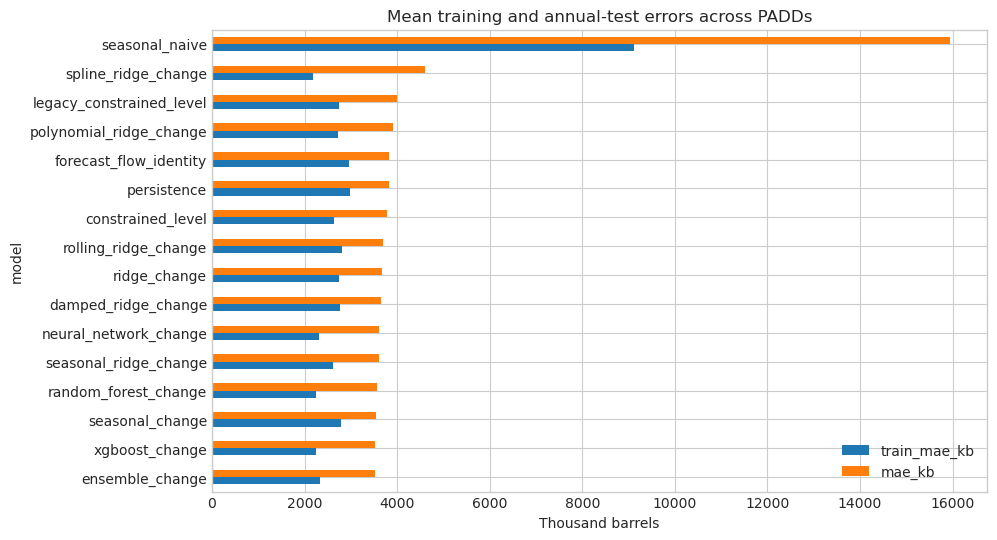

In [29]:
display(tables['regional_cv_winners'])
display(tables['national_policy_cv_metrics'].sort_values('mae_kb'))
cv=tables['padd_model_metrics'].query("split=='cv' and model not in ['selected_padd_models','deployed_policy']")
display(cv.pivot(index='model',columns='padd',values='mae_kb').style.highlight_min(axis=0))
gaps=folds.groupby('model')[['train_mae_kb','mae_kb']].mean().sort_values('mae_kb')
gaps['test_minus_train_kb']=gaps.mae_kb-gaps.train_mae_kb
display(gaps)
gaps[['train_mae_kb','mae_kb']].plot.barh(figsize=(10,6),title='Mean training and annual-test errors across PADDs')
plt.xlabel('Thousand barrels');plt.show()

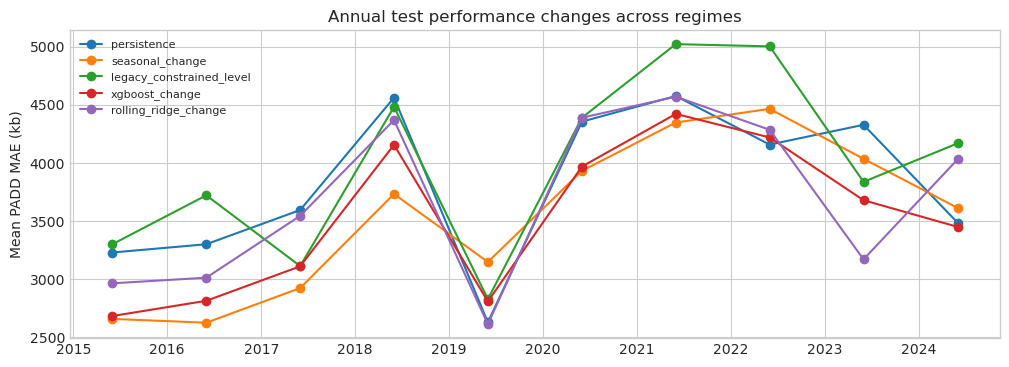

,padd,intercept_kb,stock_lag1,lag_production_kb,lag_demand_kb,lag_imports_kb,lag_exports_kb,lag_net_receipts_kb,lag_adjustments_kb,lag_transfers_kb,lag_direct_use_kb
0,1,"1,423.24",0.80,0.00,0.00,0.02,0.00,0.06,0.12,0.00,0.00
1,2,"16,508.94",0.91,0.38,0.35,0.22,0.07,0.26,0.14,0.28,0.00
2,3,"47,138.77",0.96,0.36,0.40,0.33,0.48,0.43,0.39,0.00,0.00
3,4,"1,631.09",0.90,0.08,0.09,0.05,0.00,0.03,0.07,0.00,0.00
4,5,"21,482.77",0.54,0.41,0.25,0.18,0.58,0.34,0.28,0.00,0.00


In [30]:
fig,ax=plt.subplots(figsize=(12,4))
for name in ['persistence','seasonal_change','legacy_constrained_level','xgboost_change','rolling_ridge_change']:
    g=folds[folds.model.eq(name)].groupby('test_end').mae_kb.mean()
    ax.plot(pd.to_datetime(g.index),g.values,label=name,marker='o')
ax.set(title='Annual test performance changes across regimes',ylabel='Mean PADD MAE (kb)')
ax.legend(fontsize=8);plt.show()
display(pd.read_csv(OUTPUT/'constrained_model_coefficients.csv'))

Train/test gaps can reflect overfitting **and** changes in market regimes. They are diagnostics, not a statistical significance test. The 60-month ridge is fitted on fewer observations, while its displayed training MAE is scored over the entire fold training history for comparability; this can penalize its deliberate focus on recent data.

## 8. Final one-month evaluation: July 2024–June 2026 in this run

The original regression is refitted on the same development history as every other learned candidate. Thus the comparison isolates model specification and evaluation design rather than changes in sample dates.

In [31]:
scores=tables['us_model_metrics'].query("split=='holdout'").sort_values('mae_kb')
display(scores)
lookup=scores.set_index('model')
selected=lookup.loc['deployed_policy','mae_kb']
naive=lookup.loc['persistence','mae_kb']
legacy=lookup.loc['legacy_constrained_level','mae_kb']
display(Markdown(f"**Selected policy:** `{metadata['deployed_policy']}`. National MAE is **{selected:,.0f} kb**, "
    f"versus **{naive:,.0f} kb** for persistence (**{100*(1-selected/naive):.1f}% lower**) "
    f"and **{legacy:,.0f} kb** for the original regression (**{100*(1-selected/legacy):.2f}% lower**). "
    "The gain over the old regression on this final period is small; the main case for the simpler rule is its development performance and transparency."))
display(tables['padd_model_metrics'].query("split=='holdout' and model in ['deployed_policy','legacy_constrained_level','persistence']"))

,model,split,mae_kb,rmse_kb,r2,n
33,spline_ridge_change,holdout,"9,943.28","18,028.56",0.53,24
13,neural_network_change,holdout,"10,937.10","17,026.42",0.58,24
31,selected_padd_models,holdout,"11,179.16","16,090.90",0.62,24
17,polynomial_ridge_change,holdout,"11,187.25","17,088.84",0.58,24
35,xgboost_change,holdout,"11,193.08","17,654.67",0.55,24
19,random_forest_change,holdout,"11,195.33","17,563.80",0.55,24
7,ensemble_change,holdout,"11,358.73","17,621.95",0.55,24
1,constrained_level,holdout,"11,573.28","17,424.92",0.56,24
25,seasonal_change,holdout,"11,661.90","16,394.46",0.61,24
5,deployed_policy,holdout,"11,661.90","16,394.46",0.61,24


**Selected policy:** `seasonal_change`. National MAE is **11,662 kb**, versus **13,182 kb** for persistence (**11.5% lower**) and **11,670 kb** for the original regression (**0.07% lower**). The gain over the old regression on this final period is small; the main case for the simpler rule is its development performance and transparency.

,padd,model,split,mae_kb,rmse_kb,r2,n
5,1,deployed_policy,holdout,676.88,863.98,-0.43,24
11,1,legacy_constrained_level,holdout,606.44,806.11,-0.24,24
15,1,persistence,holdout,626.88,792.38,-0.20,24
41,2,deployed_policy,holdout,"3,143.41","3,897.45",-0.32,24
47,2,legacy_constrained_level,holdout,"3,289.66","4,046.35",-0.42,24
51,2,persistence,holdout,"2,859.67","3,670.33",-0.17,24
77,3,deployed_policy,holdout,"10,010.18","14,076.16",0.63,24
83,3,legacy_constrained_level,holdout,"10,065.99","14,113.72",0.62,24
87,3,persistence,holdout,"11,164.71","17,050.05",0.45,24
113,4,deployed_policy,holdout,510.71,741.19,0.49,24


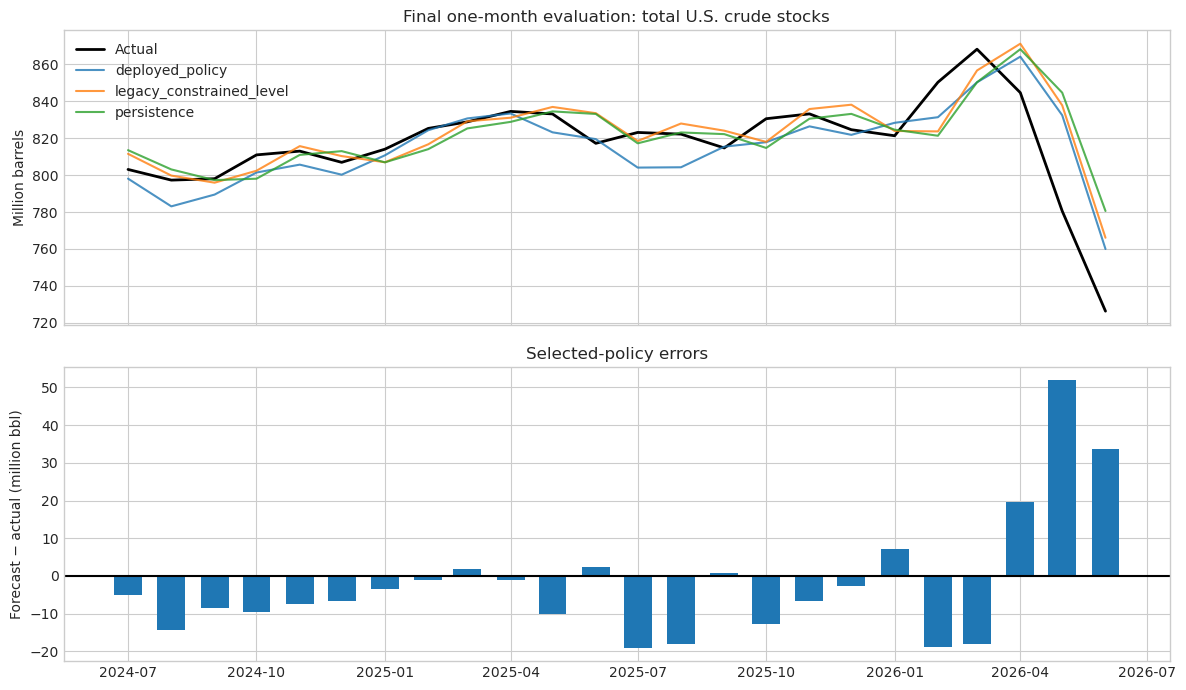

In [32]:
hold=tables['us_predictions'].query("split=='holdout'")
actual=hold[hold.model.eq('deployed_policy')]
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
axes[0].plot(actual.month,actual.actual_kb/1000,color='black',linewidth=2,label='Actual')
for name in ['deployed_policy','legacy_constrained_level','persistence']:
    g=hold[hold.model.eq(name)]
    axes[0].plot(g.month,g.predicted_kb/1000,label=name,alpha=.8)
axes[0].set(title='Final one-month evaluation: total U.S. crude stocks',ylabel='Million barrels');axes[0].legend()
axes[1].bar(actual.month,(actual.predicted_kb-actual.actual_kb)/1000,width=20)
axes[1].axhline(0,color='black');axes[1].set(ylabel='Forecast − actual (million bbl)',title='Selected-policy errors')
plt.tight_layout();plt.show()

## 9. JODI national context

JODI CRUDEOIL observations are snapshotted from the local database and currently end earlier than the refreshed EIA history. JODI is never a predictive input here and has no PADD dimension. It is a separate archive, not necessarily an independent measurement process; national definitions, coverage, revisions, and reporting dates can differ. We show the levels and differences rather than assuming they are interchangeable targets. See the [JODI stock guide](https://www.jodidata.org/oil/support/user-guide/data-available-in-the-jodi-oil-world-database.aspx).

Latest JODI month: 2026-01-01


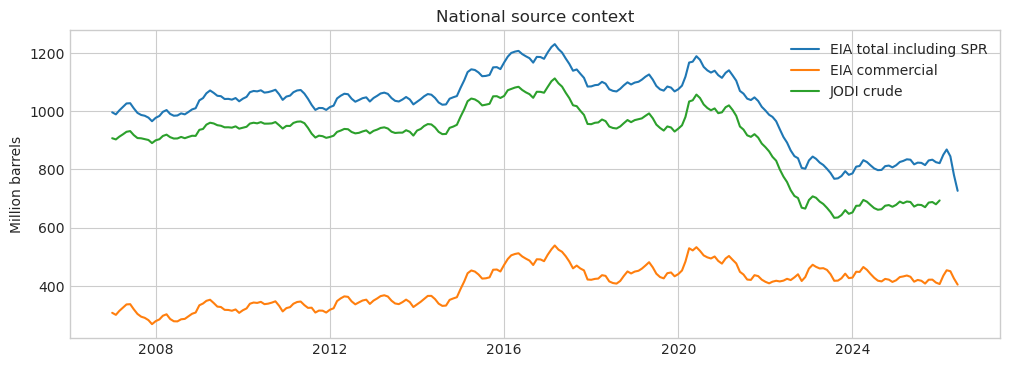

flow_breakdown,month,jodi_CLOSTLV,jodi_INDPROD,jodi_REFINOBS,jodi_STATDIFF,jodi_STOCKCH,jodi_TOTEXPSB,jodi_TOTIMPSB
223,2025-08-01,"677,551.00","427,610.00","525,210.00","-12,647.00",-925.00,"110,741.00","194,769.00"
224,2025-09-01,"670,151.00","415,333.00","493,933.00","-10,259.00","-7,400.00","131,098.00","192,039.00"
225,2025-10-01,"685,906.00","429,983.00","481,299.00","-12,200.00","15,755.00","127,961.00","182,832.00"
226,2025-11-01,"687,800.00","413,457.00","498,828.00","-30,494.00","1,894.00","116,633.00","173,404.00"
227,2025-12-01,"680,023.00","423,302.00","526,549.00","-25,287.00","-7,777.00","128,516.00","198,699.00"
228,2026-01-01,"693,262.00","422,009.00","509,507.00","-31,266.00","13,239.00","128,151.00","197,622.00"


In [33]:
history=tables['us_monthly_model']
jodi=tables['jodi_us_benchmark']
print('Latest JODI month:',jodi.month.max().date())
fig,ax=plt.subplots(figsize=(12,4))
for col,label in [('stock_kb','EIA total including SPR'),('commercial_stock_kb','EIA commercial'),('jodi_CLOSTLV','JODI crude')]:
    ax.plot(history.month,history[col]/1000,label=label)
ax.set(title='National source context',ylabel='Million barrels');ax.legend();plt.show()
display(jodi.tail(6))

## 10. Long-horizon development selection and final evaluation

A one-month model updates with actual prior stock each month. A 12-month path feeds its own predictions forward. These are different tasks.

The table below selects the 12-month policy from six development years. Final evaluation then uses 13 monthly origins, each forecasting 12 months entirely inside the final 24-month period. The overlapping paths are **correlated**, not 13 independent years. Each origin refits using only data available through that origin, with model names fixed from development selection. We also carry forward the one-month policy and compare persistence and the original regression.

,model,mae_kb,rmse_kb,r2,n
11,seasonal_change,"37,515.15","48,325.13",0.87,72
1,damped_ridge_change,"46,145.34","56,708.76",0.83,72
5,neural_network_change,"47,002.90","59,218.54",0.81,72
6,persistence,"47,528.94","58,424.50",0.82,72
13,seasonal_ridge_change,"47,585.56","58,654.32",0.82,72
8,random_forest_change,"48,241.50","59,154.67",0.81,72
2,ensemble_change,"48,528.60","59,248.80",0.81,72
10,rolling_ridge_change,"49,190.42","62,297.70",0.79,72
15,xgboost_change,"50,634.83","61,407.01",0.80,72
9,ridge_change,"51,424.34","62,066.30",0.79,72


,first_target,last_target
origin_month,,
2018-06-01,2018-07-01,2019-06-01
2019-06-01,2019-07-01,2020-06-01
2020-06-01,2020-07-01,2021-06-01
2021-06-01,2021-07-01,2022-06-01
2022-06-01,2022-07-01,2023-06-01
2023-06-01,2023-07-01,2024-06-01


,mean,median,max
model,,,
deployed_policy,"39,854.25","43,700.70","97,257.00"
legacy_constrained_level,"24,052.60","20,370.38","93,407.36"
one_step_policy_recursive,"39,854.25","43,700.70","97,257.00"
persistence,"14,930.95","12,310.00","90,946.00"


model,deployed_policy,legacy_constrained_level,one_step_policy_recursive,persistence
horizon,,,,
1,"6,919.62","5,606.37","6,919.62","6,831.92"
2,"13,812.55","9,834.27","13,812.55","10,304.08"
3,"19,698.35","11,304.91","19,698.35","11,541.15"
4,"26,149.42","15,389.19","26,149.42","13,299.23"
5,"32,385.77","17,013.33","32,385.77","12,643.23"
6,"38,273.55","19,018.56","38,273.55","12,929.38"
7,"43,106.37","22,698.79","43,106.37","12,908.77"
8,"49,140.40","27,781.80","49,140.40","15,893.85"
9,"56,478.15","32,753.91","56,478.15","18,535.54"


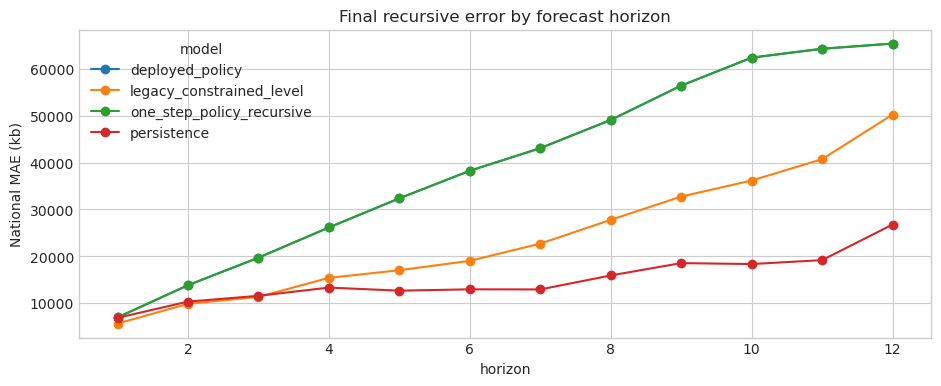

In [34]:
display(tables['horizon_policy_cv_metrics'])
cv_paths=tables['us_recursive_cv_predictions']
display(cv_paths[cv_paths.model.eq('persistence')].groupby('origin_month').agg(first_target=('month','min'),last_target=('month','max')))
assert cv_paths.month.max()<pd.Timestamp(metadata['holdout_start'])
recursive=tables['us_recursive_holdout_predictions'].copy()
recursive['abs_error_kb']=(recursive.predicted_kb-recursive.actual_kb).abs()
recursive_summary=recursive.groupby('model').abs_error_kb.agg(['mean','median','max'])
display(recursive_summary)
horizon=tables['us_recursive_horizon_metrics']
display(horizon.pivot(index='horizon',columns='model',values='mae_kb'))
horizon.pivot(index='horizon',columns='model',values='mae_kb').plot(figsize=(11,4),marker='o',title='Final recursive error by forecast horizon')
plt.ylabel('National MAE (kb)');plt.show()

**Long-horizon limitation:** The development-selected `seasonal_change` policy has recursive final-period MAE of **39,854 kb**, versus **14,931 kb** for persistence. Historical development selection does not guarantee better forecasts after a policy or market regime changes. Do not treat the selected 12-month path as a demonstrated improvement over unchanged stocks.

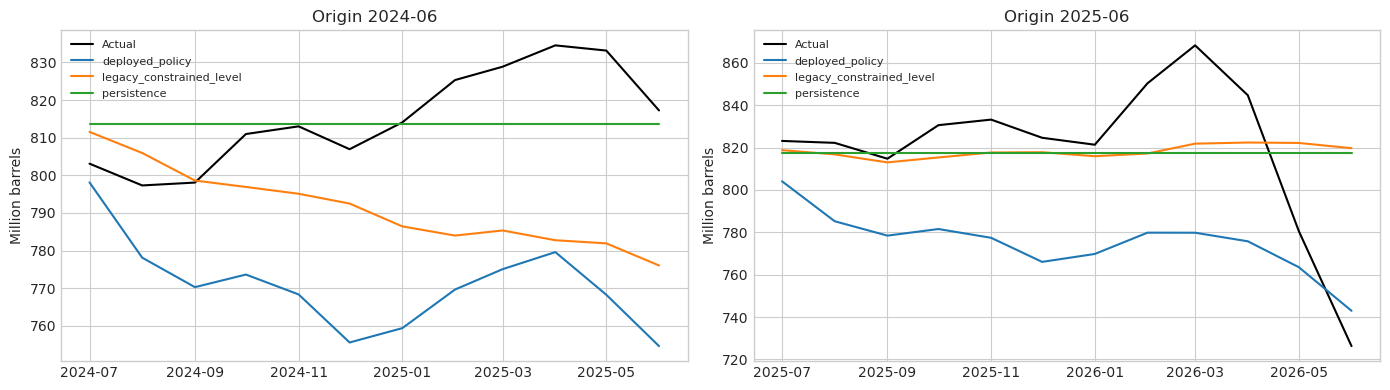

In [35]:
recursive_mae=recursive_summary.loc['deployed_policy','mean']
persistence_mae=recursive_summary.loc['persistence','mean']
display(Markdown(f"**Long-horizon limitation:** The development-selected `{metadata['horizon_policy']}` policy "
    f"has recursive final-period MAE of **{recursive_mae:,.0f} kb**, versus **{persistence_mae:,.0f} kb** for persistence. "
    "Historical development selection does not guarantee better forecasts after a policy or market regime changes. "
    "Do not treat the selected 12-month path as a demonstrated improvement over unchanged stocks."))
fig,axes=plt.subplots(1,2,figsize=(14,4))
origins=sorted(recursive.origin_month.unique())
for origin,ax in zip([origins[0],origins[-1]],axes):
    g=recursive[recursive.origin_month.eq(origin)]
    a=g[g.model.eq('deployed_policy')]
    ax.plot(a.month,a.actual_kb/1000,color='black',label='Actual')
    for name in ['deployed_policy','legacy_constrained_level','persistence']:
        t=g[g.model.eq(name)];ax.plot(t.month,t.predicted_kb/1000,label=name)
    ax.set(title=f'Origin {pd.Timestamp(origin):%Y-%m}',ylabel='Million barrels');ax.legend(fontsize=8)
plt.tight_layout();plt.show()

The SPR component explains a concrete risk: a trailing seasonal rule can extrapolate historical reserve drawdowns into a period with different government policy. A separate commercial inventory model plus explicit SPR scenarios is a sensible next research direction, but it has not been validated here. No new SPR policy assumptions are inserted to make the final evaluation look better. The forecast below retains the development-selected result and shows persistence prominently.

## 11. Twelve-month supply-and-demand outlook

The outlook starts after the last observed EIA month, **June 2026**, so it spans July 2026–June 2027. Early rows may refer to already elapsed calendar months whose observations are not in this snapshot.

The complete projected flow balance feeds a raw accounting path. The statistical stock model can disagree with it; `model_reconciliation_kb = predicted stock change − projected flow balance` exposes that disagreement. It is not an observed EIA adjustment. The raw identity path remains unclipped so impossible paths would be visible.

The one-month and 12-month policies are selected separately. `latest_forecast.csv` contains the one-month policy, while `*_forecast_12m.csv` contains the long-horizon policy. They happen to select the same rule in this run; future reruns may differ.

,month,production_kb,demand_kb,imports_kb,exports_kb,transfers_kb,adjustments_kb,balance_kb,stock_kb,identity_stock_unclipped_kb,model_reconciliation_kb
0,2026-07-01,"441,489.87","530,241.87","201,946.50","135,647.54","20,465.46","-1,063.33","-3,051.12","716,819.80","723,255.88","-6,436.08"
1,2026-08-01,"444,015.07","531,611.67","198,390.30","141,084.14","22,487.06",53.87,"-7,749.32","702,634.40","715,506.55","-6,436.08"
2,2026-09-01,"429,687.48","500,311.72","192,976.40","134,090.94","23,267.04","-11,174.99",353.06,"696,758.20","715,859.62","-6,229.26"
3,2026-10-01,"451,232.07","501,744.07","188,621.50","142,563.06","24,825.66","-6,223.33","14,148.16","704,526.20","730,007.77","-6,380.16"
4,2026-11-01,"437,982.28","506,004.52","190,212.20","138,721.08","21,410.04","-3,734.99","1,144.12","699,639.40","731,151.90","-6,030.92"
5,2026-12-01,"449,555.47","523,893.87","196,239.70","145,305.94","21,814.26","-1,996.73","-3,587.72","689,615.20","727,564.17","-6,436.48"
6,2027-01-01,"440,195.07","502,985.07","200,096.90","138,667.94","22,750.46","-10,042.13","11,347.88","694,539.60","738,912.05","-6,423.48"
7,2027-02-01,"404,063.73","446,747.25","177,296.97","136,463.30","21,873.90","-1,981.74","18,041.93","706,927.80","756,953.98","-5,653.73"
8,2027-03-01,"453,146.67","511,843.67","192,346.50","147,435.14","24,016.06","-1,963.73","8,266.88","708,759.40","765,220.85","-6,435.28"
9,2027-04-01,"439,846.48","496,260.72","185,896.60","149,223.14","22,391.64","-1,644.99","1,005.86","703,536.60","766,226.72","-6,228.66"


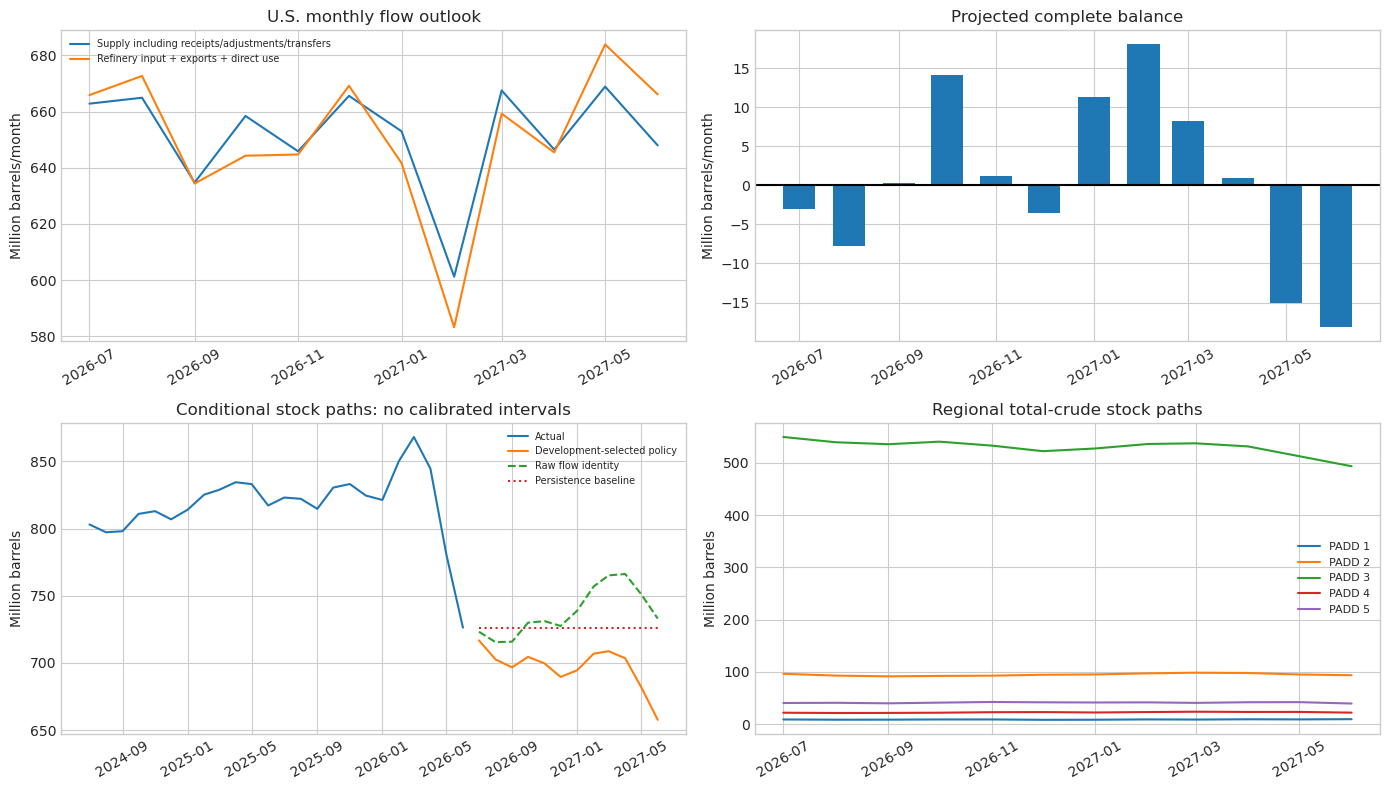

In [36]:
outlook=tables['us_forecast_12m']
display(outlook[['month','production_kb','demand_kb','imports_kb','exports_kb','transfers_kb',
    'adjustments_kb','balance_kb','stock_kb','identity_stock_unclipped_kb','model_reconciliation_kb']])
fig,axes=plt.subplots(2,2,figsize=(14,8))
for c,label in [('supply_kb','Supply including receipts/adjustments/transfers'),('total_demand_kb','Refinery input + exports + direct use')]:
    axes[0,0].plot(outlook.month,outlook[c]/1000,label=label)
axes[0,0].set(title='U.S. monthly flow outlook',ylabel='Million barrels/month');axes[0,0].legend(fontsize=7)
axes[0,1].bar(outlook.month,outlook.balance_kb/1000,width=20)
axes[0,1].axhline(0,color='black');axes[0,1].set(title='Projected complete balance',ylabel='Million barrels/month')
recent=history.tail(24)
axes[1,0].plot(recent.month,recent.stock_kb/1000,label='Actual')
axes[1,0].plot(outlook.month,outlook.stock_kb/1000,label='Development-selected policy')
axes[1,0].plot(outlook.month,outlook.identity_stock_unclipped_kb/1000,label='Raw flow identity',linestyle='--')
axes[1,0].plot(outlook.month,np.repeat(history.stock_kb.iloc[-1]/1000,12),label='Persistence baseline',linestyle=':')
axes[1,0].set(title='Conditional stock paths: no calibrated intervals',ylabel='Million barrels');axes[1,0].legend(fontsize=7)
for p,g in tables['padd_forecast_12m'].groupby('padd'):
    axes[1,1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[1,1].set(title='Regional total-crude stock paths',ylabel='Million barrels');axes[1,1].legend(fontsize=8)
for ax in axes.flat:ax.tick_params(axis='x',rotation=30)
plt.tight_layout();plt.show()

## 12. Conclusions and reproducibility

**Implemented improvements:** Correct month alignment for accounting; a complete regional balance; explicit SPR scope; historical input snapshots; candidate models on identical dates; a final period excluded from selection; selection on national error; separate recursive development tests; visible fitting warnings and model/flow discrepancies.

**What the experiments support:** A simpler seasonal-change rule improves development and one-month final-period MAE over persistence. Its final-period gain over the original regression is very small. Larger, rolling, damped, and ensemble models do not automatically improve the selected national objective. The development-selected long-horizon rule fails to beat persistence in the final period. Better validation is valuable even when it rejects a stronger performance claim.

**Remaining limitations:** Latest-vintage rather than release-vintage data; small retrospective final sample; correlated multi-horizon errors; unmodeled SPR policy changes; reporting-category changes and flagged zero assumptions; no calibrated uncertainty intervals. Commercial-only modeling with explicit reserve scenarios and actual release-vintage evaluation are future experiments, not completed performance improvements.

From this directory:

```bash
python -m pip install -r requirements.txt
python us_snd_model.py                   # saved inputs, no network
python us_snd_model.py --refresh-data    # refresh EIA; snapshot local JODI
python -m pytest -q
```

Run All executes the implementations in this notebook and reproduces the experiment and charts without importing any local Python module. Share this notebook with its `data/` folder to reproduce offline; saved outputs can be read without running code. `data/` preserves inputs and provenance; `model_output/` contains all predictions, metrics, chosen policies, coefficients, forecasts, and serialized one-month and long-horizon models. All review findings, model implementations, and limitations are included above; the companion review document is optional. Original work is archived under `legacy_results_20260905/`. The shared database is read-only.

### Reproducibility checks included in the notebook

Check source hashes, the stock decomposition, forecast timing, national aggregation, and separation of development targets from the final evaluation period. These checks run on the same inputs and outputs just used for the analysis.

In [37]:
for entry in json.loads((HERE/'data/source_manifest.json').read_text()):
    source_bytes=(HERE/'data/raw'/f"{entry['series_id']}m.xls").read_bytes()
    assert hashlib.sha256(source_bytes).hexdigest()==entry['sha256']
np.testing.assert_allclose(panel.stock_kb,panel.commercial_stock_kb+panel.spr_stock_kb)
check_history=panel[panel.padd.eq(3)].iloc[:40].copy()
before=supervised(check_history)
check_history.loc[check_history.index[-1],FLOWS+['stock_kb']]+=100000
changed=supervised(check_history)
feature_columns=[c for c in before if c not in ['actual_kb','delta_kb']]
pd.testing.assert_frame_equal(before[feature_columns],changed[feature_columns])
np.testing.assert_allclose(tables['us_forecast_12m'].stock_kb,
    tables['padd_forecast_12m'].groupby('month').stock_kb.sum())
print('Source integrity, stock scope, target-month isolation, and aggregation checks passed.')

Source integrity, stock scope, target-month isolation, and aggregation checks passed.


In [38]:
display(pd.Series(metadata,name='Run configuration'))
assert not tables['padd_predictions'].duplicated(['padd','month','model','split']).any()
assert tables['padd_forecast_12m'].groupby('month').padd.nunique().eq(5).all()
assert len(outlook)==12
assert len(tables['latest_forecast'])==6
assert not ((tables['us_recursive_cv_predictions'].month>=pd.Timestamp(metadata['holdout_start']))).any()
print('Notebook checks passed. Saved result files:')
for p in sorted(OUTPUT.iterdir()):print(p.name)

product                 Total crude oil including SPR; commercial and ...
stock_units                                 thousand barrels at month end
flow_units                            thousand barrels per calendar month
equation                S[t] = S[t-1] + field production[t] + imports[...
data_start                                                     2007-01-01
data_end                                                       2026-06-01
cv                      10 expanding folds, 12 test months each; final...
holdout_start                                                  2024-07-01
forecast_timing         One month after latest observed EIA month; con...
selection               PADD CV winners plus common-family policies; l...
deployed_policy                                           seasonal_change
horizon_policy                                            seasonal_change
horizon_selection       Lowest national MAE across six disjoint 12-mon...
flow_forecast           Last 60 months

Notebook checks passed. Saved result files:
candidate_models.json
constrained_model_coefficients.csv
fit_warnings.csv
fitted_horizon_models.joblib
fitted_models.joblib
fold_metrics.csv
horizon_policy_cv_metrics.csv
jodi_us_benchmark.csv
latest_forecast.csv
model_metadata.json
national_policy_cv_metrics.csv
padd_forecast_12m.csv
padd_model_coefficients.csv
padd_model_metrics.csv
padd_monthly_model.csv
padd_predictions.csv
recursive_cv_predictions.csv
recursive_holdout_metrics.csv
recursive_holdout_predictions.csv
regional_cv_winners.csv
selected_models.csv
us_forecast_12m.csv
us_model_metrics.csv
us_monthly_model.csv
us_predictions.csv
us_recursive_cv_predictions.csv
us_recursive_holdout_predictions.csv
us_recursive_horizon_metrics.csv
